# Practical Statistics for Data Scientists
# AI-Assisted Statistics for Data Scientists
# Chapter 2: Data and Sampling Distributions
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
library(boot)
library(tidyverse)

set.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
DATA_DIR <- '../../data'


── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Data and Sampling Distributions
### Sampling Distribution of a Statistic

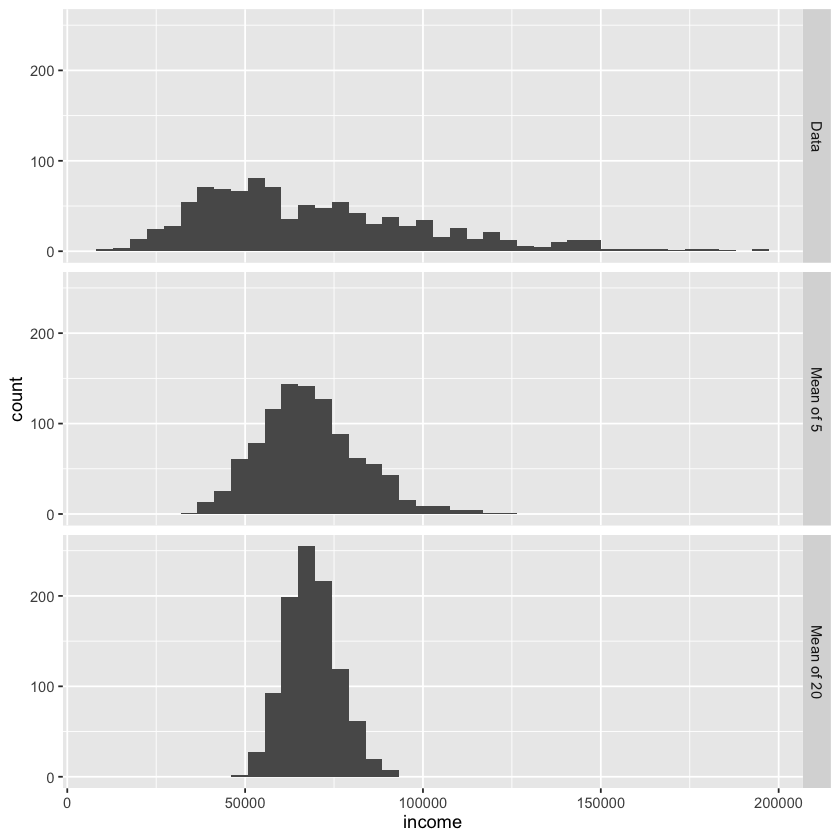

In [1]:
loans_income <- read_csv(file.path(DATA_DIR, "loans_income.csv"), show_col_types = FALSE) %>%
  pull(x)

# take a simple random sample
samp_data <- data.frame(income = sample(loans_income, 1000),
  type = "Data")
# take a sample of means of 5 values
samp_mean_05 <- tibble(
  income = replicate(1000, mean(sample(loans_income, 5))),
  type = "Mean of 5"
)
# take a sample of means of 20 values
samp_mean_20 <- tibble(
  income = replicate(1000, mean(sample(loans_income, 20))),
  type = "Mean of 20"
)
income <- bind_rows(samp_data, samp_mean_05, samp_mean_20) %>%
  mutate(type = factor(type,
      levels = c("Data", "Mean of 5", "Mean of 20"))
  )

# plot the histograms
ggplot(income, aes(x = income)) +
  geom_histogram(bins = 40) +
  facet_grid(type ~ .)

### The Bootstrap

In [1]:
stat_fun <- function(x, idx) median(x[idx])
boot_obj <- boot(loans_income, R = 1000, statistic = stat_fun)

In [1]:
boot_obj


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = loans_income, statistic = stat_fun, R = 1000)


Bootstrap Statistics :
    original   bias    std. error
t1*    62000 -78.0335     218.435

### Normal Distribution
#### Standard Normal and QQ-Plots

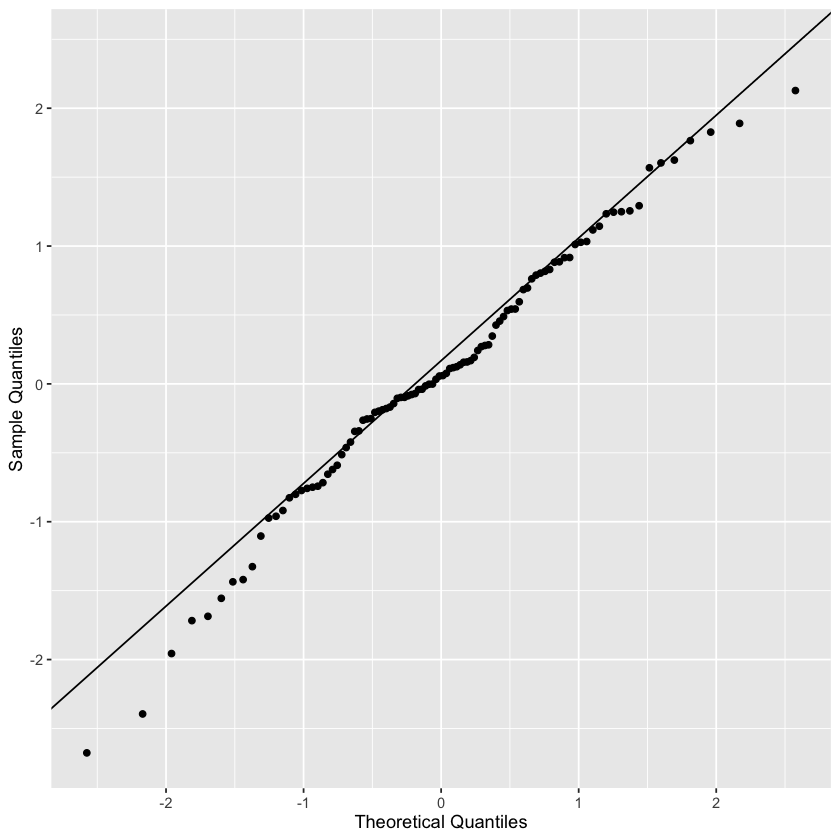

In [1]:
norm_samp <- rnorm(100)
ggplot(tibble(y = norm_samp), aes(sample = y)) +
  geom_qq() +
  geom_qq_line() +
  labs(x = "Theoretical Quantiles", y = "Sample Quantiles")

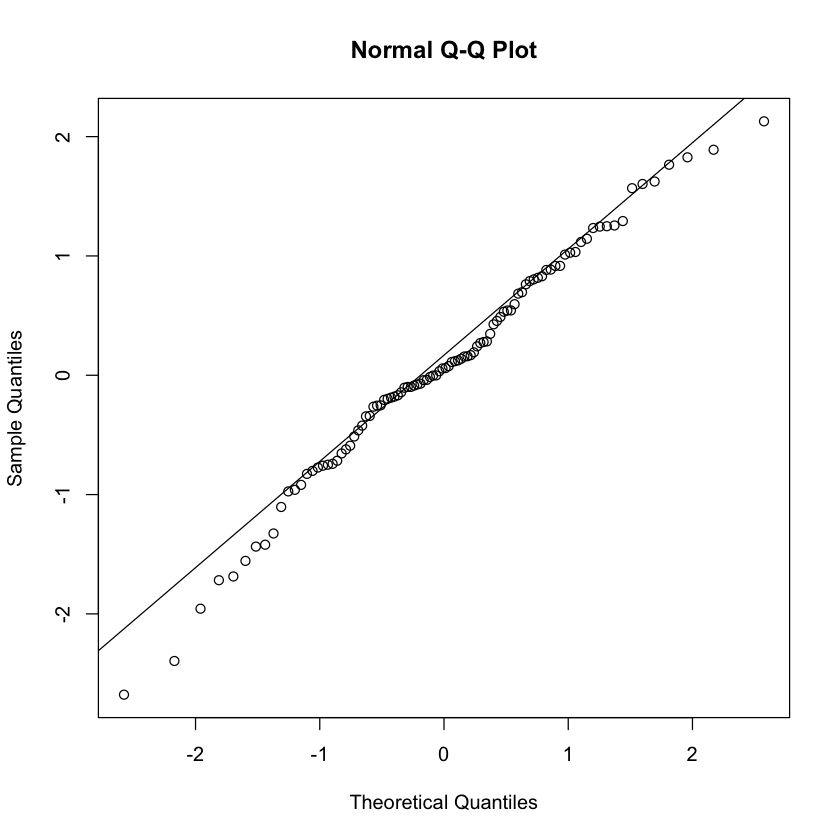

In [1]:
# alternative using qqnorm
qqnorm(norm_samp)
qqline(norm_samp)

### Long-Tailed Distributions

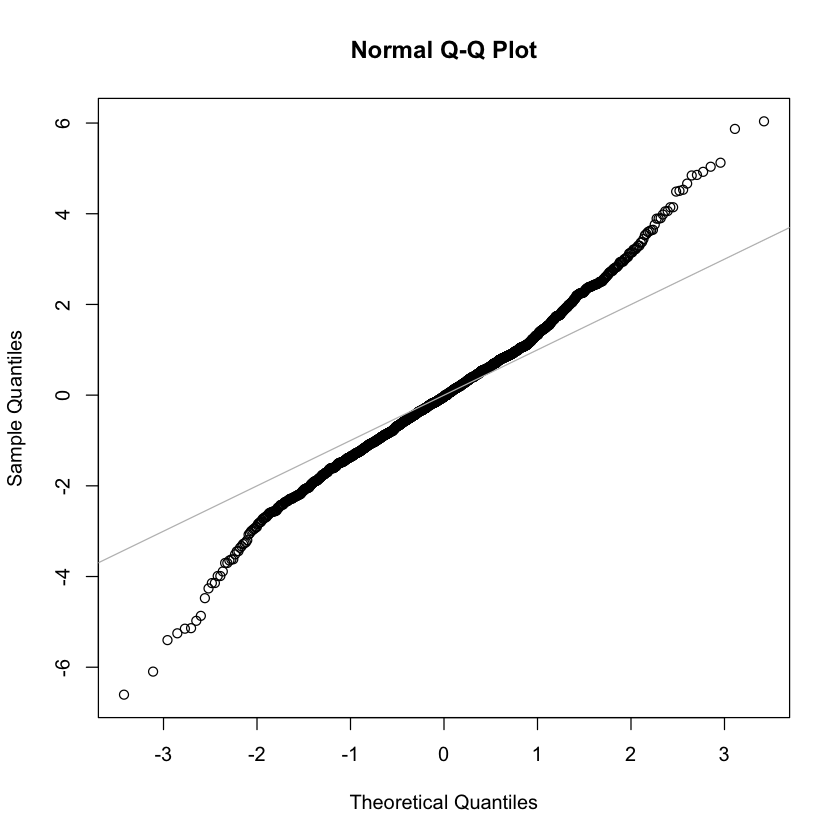

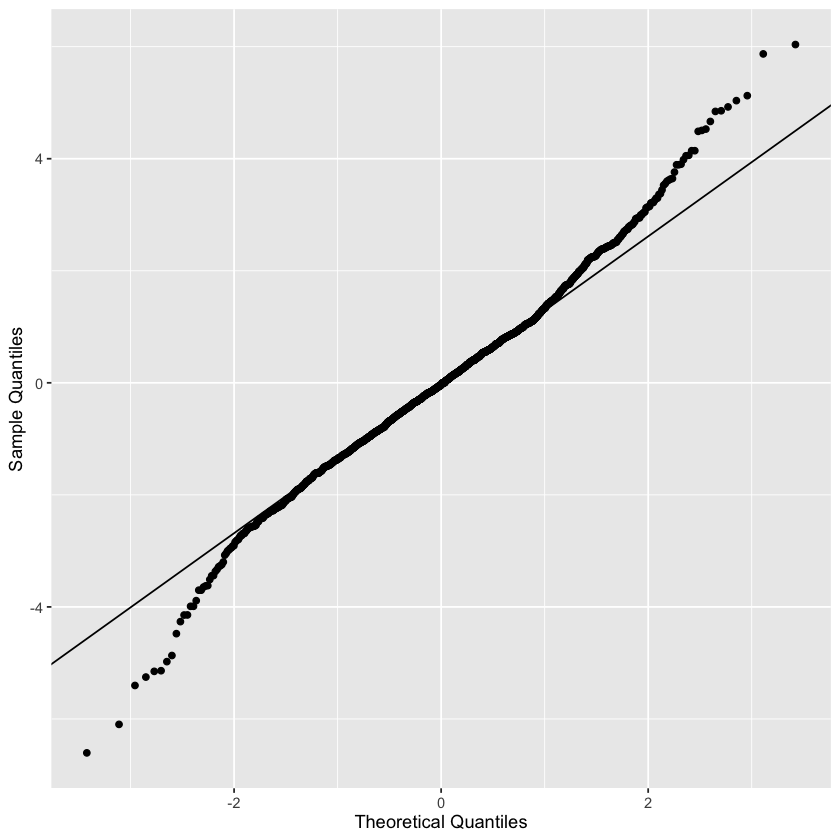

In [1]:
sp500_px <- read_csv(file.path(DATA_DIR, "sp500_data.csv.gz"), show_col_types = FALSE)

nflx <- sp500_px[, "NFLX"]
nflx <- diff(log(nflx[nflx > 0]))
qqnorm(nflx)
abline(a = 0, b = 1, col = "grey")
ggplot(tibble(y = nflx), aes(sample = y)) +
  geom_qq() +
  geom_qq_line() +
  labs(x = "Theoretical Quantiles", y = "Sample Quantiles")

### Binomial Distribution

In [1]:
dbinom(x = 2, size = 5, prob = 0.1)

[1] 0.0729

In [1]:
pbinom(q = 2, size = 5, prob = 0.1)

[1] 0.99144

### Poisson and Related Distributions
#### Poisson Distributions

In [1]:
rpois(n = 100, lambda = 2)

[1] 4 4 2 2 1 3 3 2 1 2 1 1 4 2 5 0 1 1 1 1 0 4 4 3 2 1 3 2 3 1 2 2 4 4 2 2 2
 [38] 1 0 2 2 1 2 0 0 1 2 1 5 3 1 1 2 3 0 0 4 6 3 1 3 3 1 2 1 1 0 3 0 1 2 2 3 2
 [75] 3 3 3 0 1 1 2 2 1 2 3 4 3 2 0 1 6 0 2 4 2 1 3 4 1 1

#### Exponential Distribution

In [1]:
rexp(n = 100, rate = 0.2)

[1]  4.07346734  2.17073739  5.14865004 16.53458100  3.15990128  1.44639363
  [7]  6.71159670  1.94148521  3.07380139  0.14816031  0.94851643  4.01592231
 [13]  4.23500813  7.94450586  1.65147616  7.66297467  1.96764111  2.75784581
 [19] 10.96168102  1.16213261  0.61102357  4.12550939  1.94364576  0.55026757
 [25]  0.42957327  2.45168525  2.29825830  9.05509853  0.11316217  2.36435897
 [31]  2.71259286  1.74003456  1.65351371  1.26302835  3.32789666  3.74267856
 [37]  3.53726076 17.26188261  3.82375830 10.24221414  1.96016300  0.96980445
 [43]  7.28190596  4.49437355  4.74370156  4.57815579  2.78896367  1.75152965
 [49]  3.93607254  1.44091343  8.55701424  2.73624697  3.79334880  1.83407396
 [55]  4.73760572  1.57229130  1.71220615  0.67121754  4.86623665  3.11898902
 [61]  1.76357315 13.97545222  1.05073974  2.81140206  0.03395641 16.82321384
 [67]  2.59544946  0.67558290  4.13565155  1.05694528  1.10359495  6.06149924
 [73] 10.07772813  6.65324248  4.56595594  1.01110235  4.06021467  1.16836541
 [79]  5.74968780  1.89856448 18.66252403 24.77096539  5.41567666  0.38344737
 [85] 10.16532329  5.72523382  5.61170036  1.90297222  2.44148714  3.17490431
 [91]  6.89915769  0.23421290 13.99594583  3.11688455 14.30269364  8.37592996
 [97]  0.93599912  0.56194351  3.91452776  3.79357926

#### Weibull Distribution

In [1]:
rweibull(n = 100, shape = 1.5, scale = 5000)

[1]  7707.2870  2406.5747  6874.0074  8596.6947  2514.3138  3999.7921
  [7]  3369.8528  4048.1785  9375.1513  1706.8557  3433.8003  2726.2752
 [13]  4523.9387  7040.2923  7364.4615  5659.5778  7102.7263  6057.7507
 [19]  2036.1486 11028.2003  3586.4103  4146.8145  2831.1659  9959.8099
 [25]  7602.8909  1120.3865  5846.3944  6447.5121  1819.2396  2724.5239
 [31]   478.1061  4081.7044  4798.2257  3309.6343  5000.1535  2810.7907
 [37]  8552.5192  7541.2918  5075.8178  3208.4934   982.7275  7650.7401
 [43]  9842.4535  4448.3576  1275.9499  2552.7549   715.8189  2799.8493
 [49]  4510.0642  5538.3474  2091.4848  1877.2346 10337.0965  3933.0951
 [55]  2834.4235  6778.5425  7326.2338  4974.0059  4423.4556  6580.7693
 [61]  1552.7165  4354.3609  4426.6340  5217.0391  4174.5196  5861.5523
 [67]  6719.0646  1874.5244  4619.5597  4372.1938  3521.1949  2788.1942
 [73]  8264.1172  8450.5781 15525.8471  4114.4116  8050.7286  2987.4661
 [79]  3381.9668  6107.0580  5807.5831  1023.9040  6669.2130  3642.4725
 [85]  2675.1443  9486.6622  8003.2702  7979.9733  2016.2279  6423.2686
 [91]  7612.6723  1599.4113  8025.0593  5499.3829  1870.0076  4353.9364
 [97]  2650.8710   950.4002  4151.6942  6611.0451

# Supplementary Material
## Figure 2-9 Bootstrap confidence interval for the annual income of loan applicants, based on a sample of 20

ci,y
<dbl>,<dbl>
51643.09,9
65262.95,11


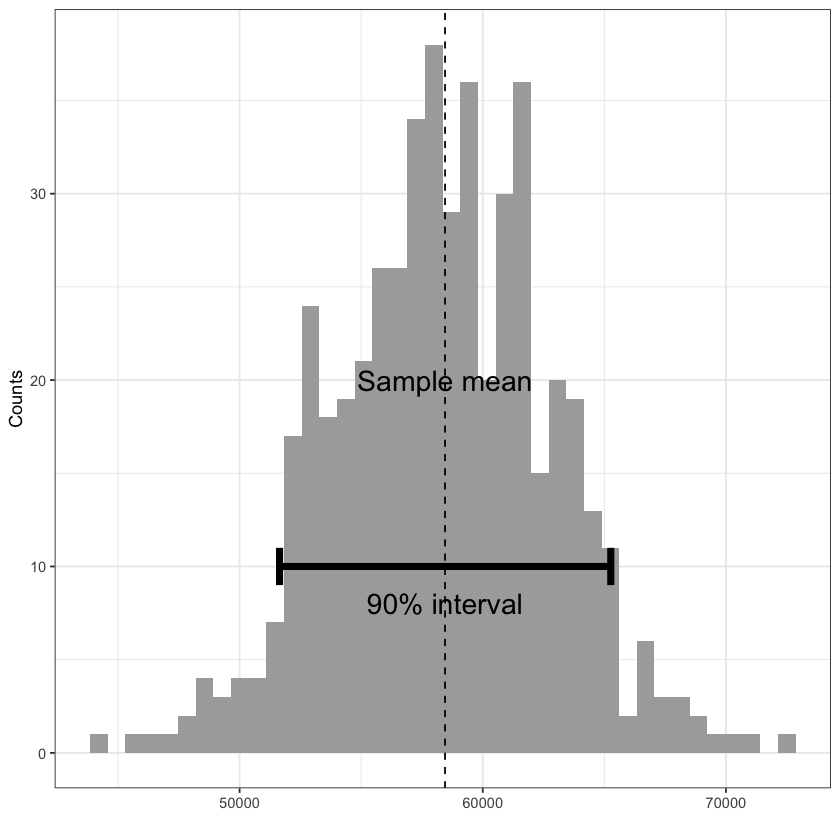

In [1]:
loans_income <- read_csv(file.path(DATA_DIR, "loans_income.csv"), show_col_types = FALSE) %>%
  pull(x)

set.seed(7)
sample20 <- sample(loans_income, 20)
sample_mean <- mean(sample20)

stat_fun <- function(x, idx) mean(x[idx])
boot_obj <- boot(sample20, R = 500, statistic = stat_fun)
boot_ci <- boot.ci(boot_obj, conf = 0.9, type = "basic")
df <- data.frame(mean = boot_obj$t)
ci90 <- boot_ci$basic[4:5]
ci <- data.frame(ci = ci90, y = c(9, 11))
ci

ggplot(df, aes(x = mean)) +
  geom_histogram(bins = 40, fill = "#AAAAAA") +
  geom_vline(xintercept = sample_mean, linetype = 2) +
  geom_path(aes(x = ci, y = 10), data = ci, linewidth = 2) +
  geom_path(aes(x = ci90[1], y = y), data = ci, linewidth = 2) +
  geom_path(aes(x = ci90[2], y = y), data = ci, linewidth = 2) +
  annotate("text", x = sample_mean, y = 20, label = "Sample mean", size = 6) +
  annotate("text", x = sample_mean, y = 8, label = "90% interval", size = 6) +
  theme_bw() +
  labs(x = "", y = "Counts")

## Visualization of Distributions
### Poisson Distribution

### Exponential Distribution

### Weibull Distribution